# EDA ERA5 — Variables Meteorologicas sobre Cali
---
**Proyecto:** GeoVision-CLIP Cali
**Coleccion:** `ECMWF/ERA5/HOURLY`
**Periodo:** 2019-01-01 a 2023-12-31
**Region:** BBox `[-76.65, 3.30, -76.30, 3.65]`

### Objetivo
Caracterizar variables meteorologicas que actuan como covariables proxy para
dispersion de contaminantes en el modelo GeoVision-CLIP.

### Nota sobre ERA5 vs ERA5-Land
Usamos `ECMWF/ERA5/HOURLY` (reanalisis atmosferico completo), NO ERA5-Land.
ERA5 incluye `boundary_layer_height` (critica para dispersion), pero NO tiene
`relative_humidity` como banda directa — la calculamos via formula de Magnus.

In [1]:
!pip install -q earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 20.0 MB/s eta 0:00:00


In [2]:
import ee, geemap, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Librerias OK')

Librerias OK


In [ ]:
# Reautenticar con token fresco para GEE (evita timeout)
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='proyecto3ia-494900')
print('GEE autenticado y conectado.')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=3ptQhrc-Qxxut9cdsCHLnAhE-xIjPjCTAFO_zmXdtvk&tc=NRI_P3oegPRbIIgloXFhi_7eAywSxZZB2LO2lrs6sAg&cc=hb-c7o_iW3GXN3v6uK5uk60gMetktX1HwlJr8fHAQXU

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1AeoWuM_aLt0FKTudZylNkO719GHdwDpjiGfcQ4FPyDkOPlKp9e5pJ5lJ1f4

Successfully saved authorization token.
GEE autenticado y conectado.


/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [4]:
# 3. COLECCION ERA5 HOURLY
COLLECTION_ID = 'ECMWF/ERA5/HOURLY'
era5 = ee.ImageCollection(COLLECTION_ID)
bands_info = era5.first().getInfo()['bands']
print(f'Coleccion: {COLLECTION_ID}')
print(f'Bandas disponibles: {len(bands_info)}')
print('\nPrimeras 30 bandas:')
for b in bands_info[:30]:
    print(f'  {b["id"]}')

Coleccion: ECMWF/ERA5/HOURLY
Bandas disponibles: 292

Primeras 30 bandas:
  dewpoint_temperature_2m
  temperature_2m
  ice_temperature_layer_1
  ice_temperature_layer_2
  ice_temperature_layer_3
  ice_temperature_layer_4
  mean_sea_level_pressure
  sea_surface_temperature
  skin_temperature
  surface_pressure
  u_component_of_wind_100m
  v_component_of_wind_100m
  u_component_of_neutral_wind_10m
  u_component_of_wind_10m
  v_component_of_neutral_wind_10m
  v_component_of_wind_10m
  instantaneous_10m_wind_gust
  mean_boundary_layer_dissipation
  mean_convective_precipitation_rate
  mean_convective_snowfall_rate
  mean_eastward_gravity_wave_surface_stress
  mean_eastward_turbulent_surface_stress
  mean_evaporation_rate
  mean_gravity_wave_dissipation
  mean_large_scale_precipitation_fraction
  mean_large_scale_precipitation_rate
  mean_large_scale_snowfall_rate
  mean_northward_gravity_wave_surface_stress
  mean_northward_turbulent_surface_stress
  mean_potential_evaporation_rate


/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


### Variables seleccionadas (6 bandas + HR calculada)
| Banda | Unidad | Relevancia |
|-------|--------|-----------|
| `temperature_2m` | K | Reacciones fotoquimicas NO2->O3 |
| `dewpoint_temperature_2m` | K | Permite calcular HR (Magnus) |
| `u/v_component_of_wind_10m` | m/s | Transporte y dispersion |
| `boundary_layer_height` | m | Dispersion vertical (predictor clave) |
| `total_precipitation` | m | Lavado atmosferico |

> `relative_humidity` se calcula a partir de T y Td con Magnus.

In [5]:
METEO_BANDS = [
    'temperature_2m',
    'dewpoint_temperature_2m',
    'u_component_of_wind_10m',
    'v_component_of_wind_10m',
    'boundary_layer_height',
    'total_precipitation',
]
print('Bandas a extraer:')
for i, b in enumerate(METEO_BANDS, 1):
    print(f'  {i}. {b}')

Bandas a extraer:
  1. temperature_2m
  2. dewpoint_temperature_2m
  3. u_component_of_wind_10m
  4. v_component_of_wind_10m
  5. boundary_layer_height
  6. total_precipitation


In [6]:
# 4. FILTROS
BBOX = ee.Geometry.BBox(-76.65, 3.30, -76.30, 3.65)
START, END = '2019-01-01', '2023-12-31'

era5_cali = (era5.filterDate(START, END)
                .filterBounds(BBOX)
                .select(METEO_BANDS))

print(f'Periodo: {START} -> {END}')
print(f'Imagenes horarias: {era5_cali.size().getInfo():,}')

Periodo: 2019-01-01 -> 2023-12-31
Imagenes horarias: 43,800


In [7]:
# 5. MAPA INTERACTIVO (muestra 30 dias para no exceder cuota)
Map = geemap.Map(center=[3.47, -76.50], zoom=10)
sample = era5_cali.filterDate('2023-06-01','2023-06-30').mean()
temp_c = sample.select('temperature_2m').subtract(273.15)
Map.addLayer(temp_c, {'min':15,'max':35,'palette':['blue','cyan','green','yellow','orange','red']}, 'Temp media °C')
Map.addLayer(BBOX, {'color':'black'}, 'BBox')
Map.add_colorbar({'min':15,'max':35,'palette':['blue','cyan','green','yellow','orange','red']}, label='°C')
Map

Map(center=[3.47, -76.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 6. Extraccion de series mensuales

In [8]:
month_starts = pd.date_range(START, END, freq='MS')
rows = []
for i in range(len(month_starts)):
    start = month_starts[i].strftime('%Y-%m-%d')
    end = (month_starts[i+1].strftime('%Y-%m-%d') if i+1 < len(month_starts) else '2024-01-01')
    monthly = era5_cali.filterDate(start, end).mean().clip(BBOX)
    stats = monthly.reduceRegion(
        reducer=ee.Reducer.mean().combine(reducer2=ee.Reducer.stdDev(), sharedInputs=True),
        geometry=BBOX, scale=5000, maxPixels=1e9)
    props = stats.getInfo()
    props['date'] = start
    rows.append(props)
    if (i+1) % 12 == 0:
        print(f'  {i+1}/{len(month_starts)} meses')

df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Conversiones
df['temperature_2m_mean'] -= 273.15
df['dewpoint_temperature_2m_mean'] -= 273.15

# HR via Magnus
T, Td = df['temperature_2m_mean'], df['dewpoint_temperature_2m_mean']
df['relative_humidity_mean'] = 100 * (np.exp((17.625*Td)/(243.04+Td)) / np.exp((17.625*T)/(243.04+T)))

df['total_precipitation_mean'] *= 1000
df['wind_speed_mean'] = np.sqrt(df['u_component_of_wind_10m_mean']**2 + df['v_component_of_wind_10m_mean']**2)
df['wind_direction_mean'] = (np.degrees(np.arctan2(df['v_component_of_wind_10m_mean'], df['u_component_of_wind_10m_mean']))+360)%360
df['year'], df['month'] = df['date'].dt.year, df['date'].dt.month

print(f'Meses: {len(df)}')
df.head()

  12/60 meses
  24/60 meses
  36/60 meses
  48/60 meses
  60/60 meses
Meses: 60


,boundary_layer_height_mean,boundary_layer_height_stdDev,dewpoint_temperature_2m_mean,dewpoint_temperature_2m_stdDev,temperature_2m_mean,temperature_2m_stdDev,total_precipitation_mean,total_precipitation_stdDev,u_component_of_wind_10m_mean,u_component_of_wind_10m_stdDev,v_component_of_wind_10m_mean,v_component_of_wind_10m_stdDev,date,relative_humidity_mean,wind_speed_mean,wind_direction_mean,year,month
0,258.367665,17.517921,18.745214,1.342828,21.840567,1.403527,0.376432,0.000194,0.181951,0.142023,-0.655612,0.298636,2019-01-01,82.595505,0.680392,285.510811,2019,1
1,269.142425,24.264644,19.454641,1.174338,22.149672,1.431661,0.573793,0.000381,0.205073,0.187259,-0.796568,0.324602,2019-02-01,84.718037,0.822542,284.437039,2019,2
2,276.290020,23.826819,19.242039,1.095190,22.316228,1.406669,0.367495,0.000271,0.055360,0.174340,-0.667887,0.309521,2019-03-01,82.761431,0.670178,274.738275,2019,3
3,270.508194,21.762856,19.420400,1.067295,22.139356,1.380917,0.541602,0.000282,0.090950,0.203216,-0.604401,0.303184,2019-04-01,84.591005,0.611206,278.557666,2019,4
4,250.480900,20.087300,19.205015,1.166437,22.013919,1.458751,0.485662,0.000478,0.320004,0.184575,-0.721730,0.333161,2019-05-01,84.105178,0.789491,293.911771,2019,5


## 7. Serie temporal — Temperatura

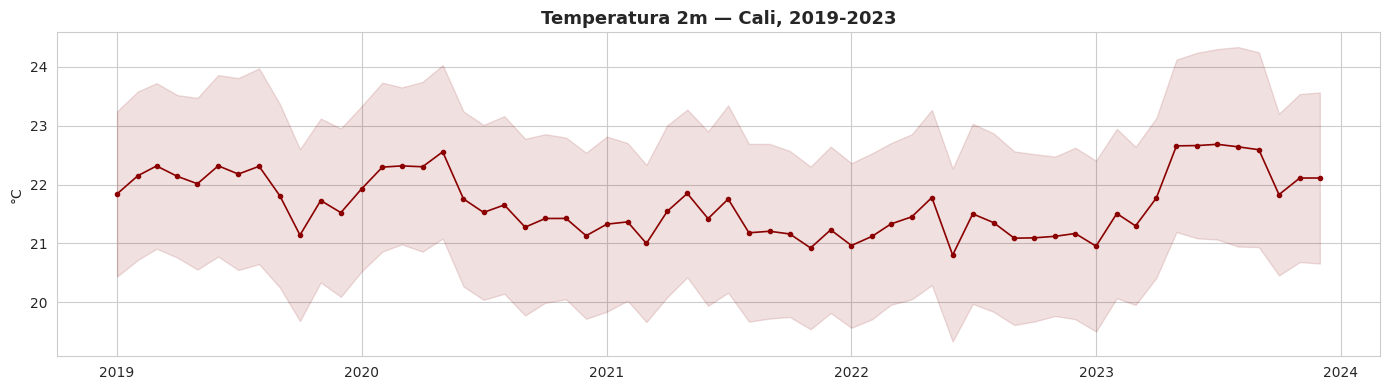

In [9]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df['date'], df['temperature_2m_mean'], 'o-', color='darkred', markersize=3, lw=1.2)
ax.fill_between(df['date'], df['temperature_2m_mean']-df['temperature_2m_stdDev'], df['temperature_2m_mean']+df['temperature_2m_stdDev'], color='darkred', alpha=0.12)
ax.set_title('Temperatura 2m — Cali, 2019-2023', fontsize=13, weight='bold')
ax.set_ylabel('°C'); plt.tight_layout(); plt.savefig('era5_temperatura_serie.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Multi-panel (T2m, BLH, HR, Viento) → era5_variables.png

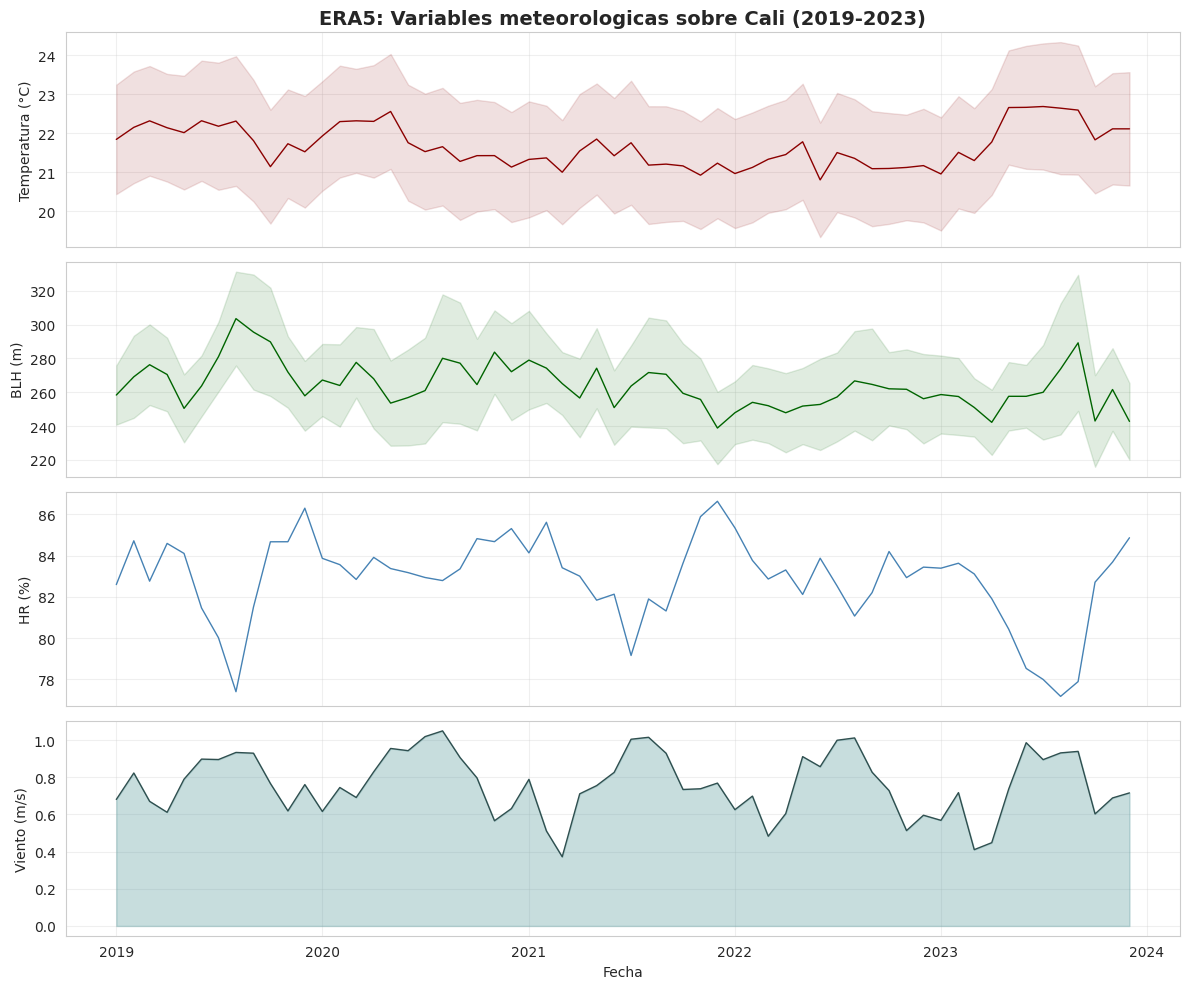

In [10]:
# TODO: Figura para LaTeX
fig, axes = plt.subplots(4,1,figsize=(12,10),sharex=True)
axes[0].plot(df['date'],df['temperature_2m_mean'],color='darkred',lw=1)
axes[0].fill_between(df['date'],df['temperature_2m_mean']-df['temperature_2m_stdDev'],df['temperature_2m_mean']+df['temperature_2m_stdDev'],color='darkred',alpha=0.12)
axes[0].set_ylabel('Temperatura (°C)'); axes[0].set_title('ERA5: Variables meteorologicas sobre Cali (2019-2023)',fontsize=14,weight='bold')
axes[1].plot(df['date'],df['boundary_layer_height_mean'],color='darkgreen',lw=1)
axes[1].fill_between(df['date'],df['boundary_layer_height_mean']-df['boundary_layer_height_stdDev'],df['boundary_layer_height_mean']+df['boundary_layer_height_stdDev'],color='darkgreen',alpha=0.12)
axes[1].set_ylabel('BLH (m)')
axes[2].plot(df['date'],df['relative_humidity_mean'],color='steelblue',lw=1); axes[2].set_ylabel('HR (%)')
axes[3].fill_between(df['date'],df['wind_speed_mean'],color='cadetblue',alpha=0.35)
axes[3].plot(df['date'],df['wind_speed_mean'],color='darkslategray',lw=1); axes[3].set_ylabel('Viento (m/s)'); axes[3].set_xlabel('Fecha')
for ax in axes: ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('era5_variables.png',dpi=150,bbox_inches='tight'); plt.show()

## 9. Ciclo estacional

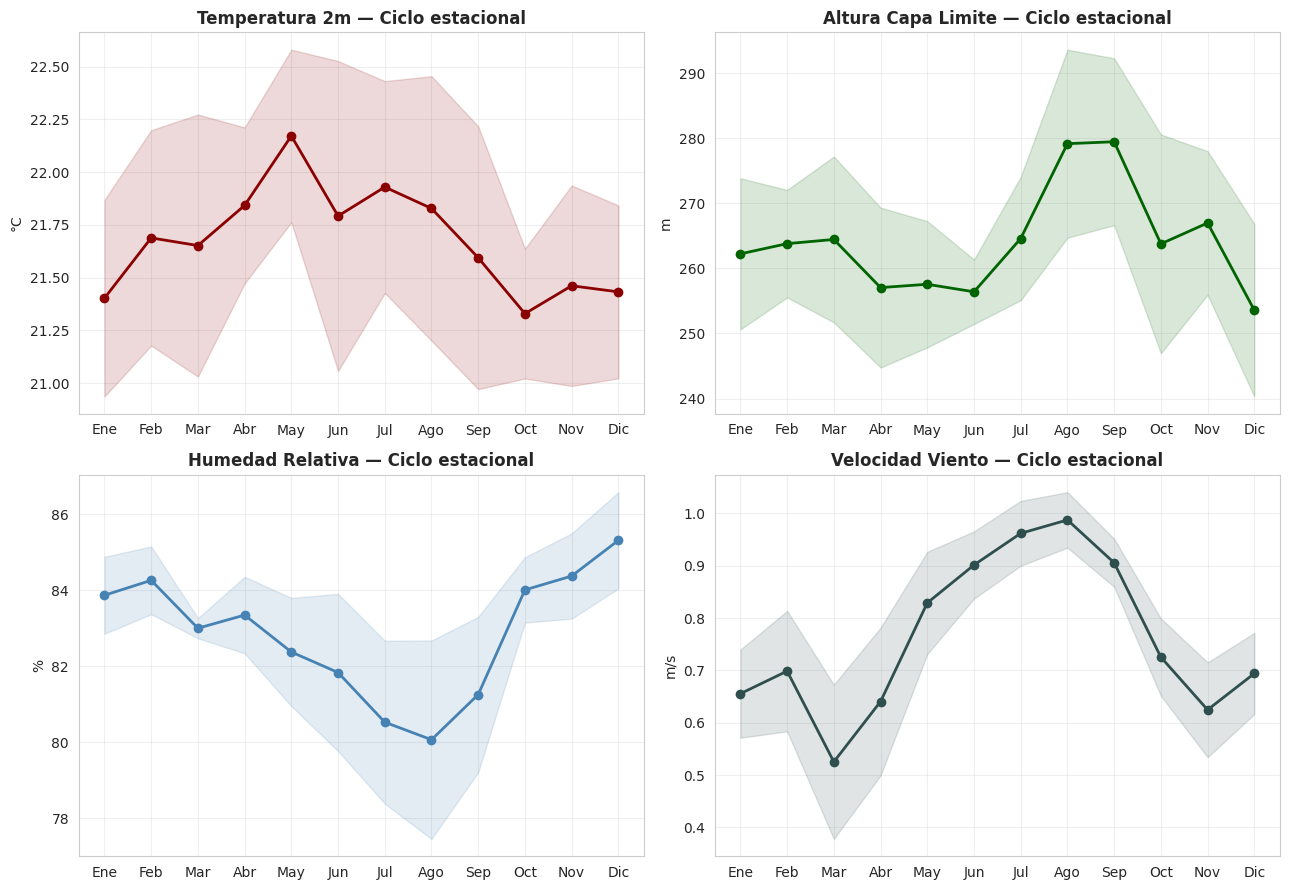

In [11]:
fig,axes=plt.subplots(2,2,figsize=(13,9))
months=range(1,13); mlabels=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for ax,(col,color,ylabel,title) in zip(axes.flat,[
    ('temperature_2m_mean','darkred','°C','Temperatura 2m'),
    ('boundary_layer_height_mean','darkgreen','m','Altura Capa Limite'),
    ('relative_humidity_mean','steelblue','%','Humedad Relativa'),
    ('wind_speed_mean','darkslategray','m/s','Velocidad Viento')]):
    m=df.groupby('month')[col].agg(['mean','std'])
    ax.plot(months,m['mean'],'o-',color=color,lw=2,ms=6)
    ax.fill_between(months,m['mean']-m['std'],m['mean']+m['std'],color=color,alpha=0.15)
    ax.set_title(f'{title} — Ciclo estacional',fontsize=12,weight='bold')
    ax.set_ylabel(ylabel); ax.set_xticks(months); ax.set_xticklabels(mlabels); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

## 10. KDE — Distribuciones

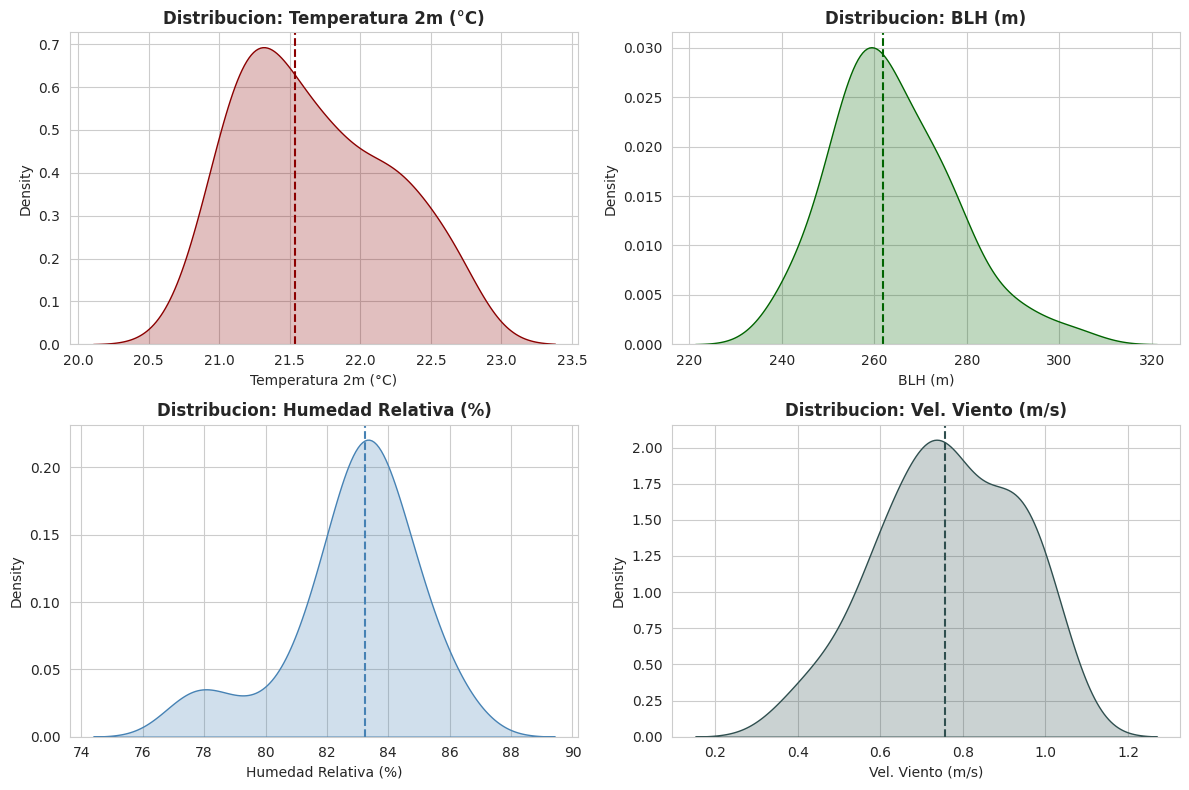

In [12]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,(col,color,label) in zip(axes.flat,[
    ('temperature_2m_mean','darkred','Temperatura 2m (°C)'),
    ('boundary_layer_height_mean','darkgreen','BLH (m)'),
    ('relative_humidity_mean','steelblue','Humedad Relativa (%)'),
    ('wind_speed_mean','darkslategray','Vel. Viento (m/s)')]):
    sns.kdeplot(df[col],color=color,fill=True,alpha=0.25,ax=ax)
    ax.axvline(df[col].median(),color=color,ls='--',lw=1.5)
    ax.set_title(f'Distribucion: {label}',fontsize=12,weight='bold')
    ax.set_xlabel(label)
plt.tight_layout(); plt.show()

## 11. Boxplots mensuales

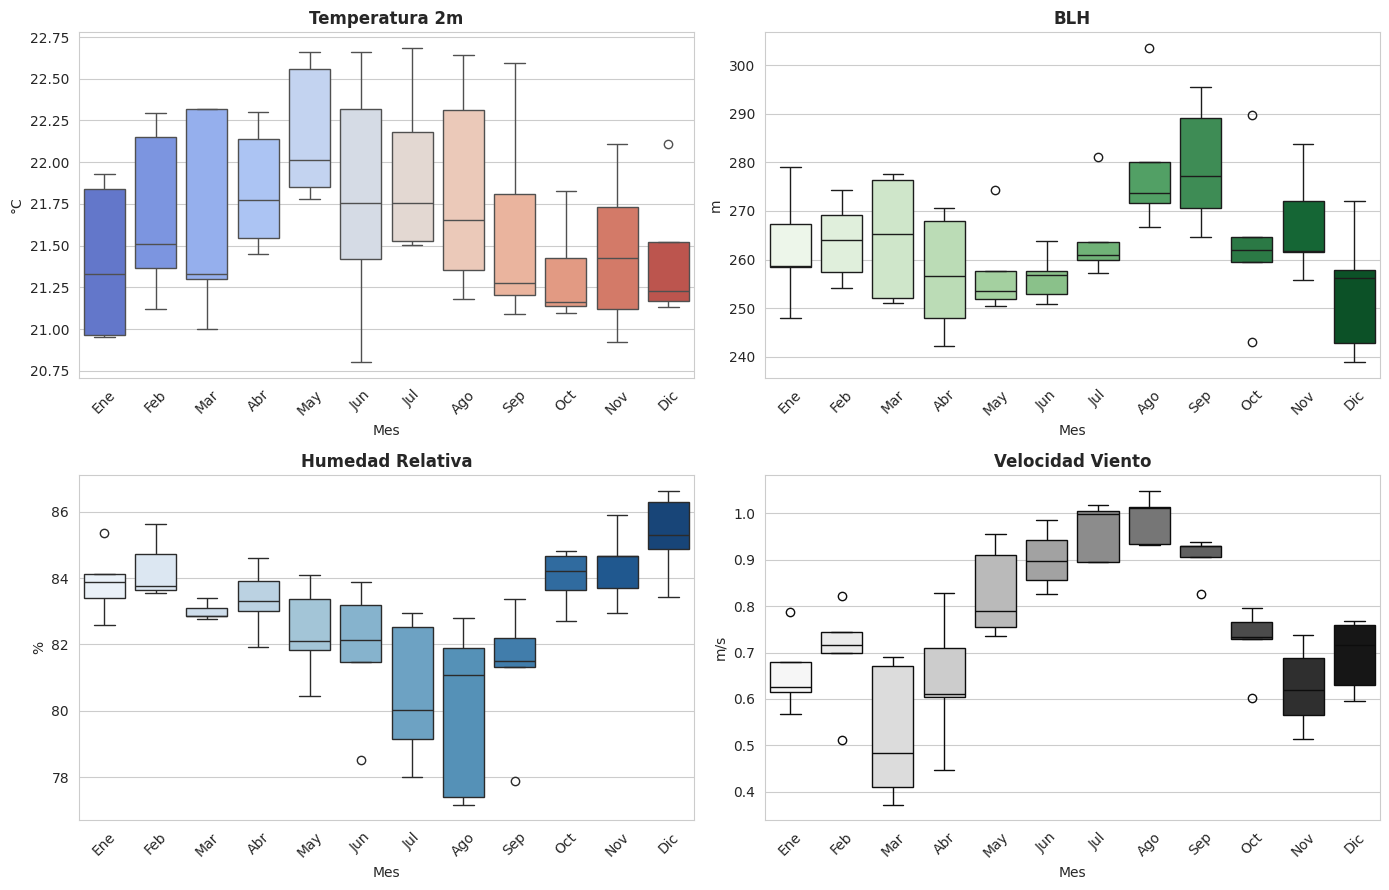

In [13]:
fig,axes=plt.subplots(2,2,figsize=(14,9))
for ax,(col,palette,title,ylabel) in zip(axes.flat,[
    ('temperature_2m_mean','coolwarm','Temperatura 2m','°C'),
    ('boundary_layer_height_mean','Greens','BLH','m'),
    ('relative_humidity_mean','Blues','Humedad Relativa','%'),
    ('wind_speed_mean','Greys','Velocidad Viento','m/s')]):
    sns.boxplot(x='month',y=col,data=df,palette=palette,ax=ax)
    ax.set_title(title,fontsize=12,weight='bold'); ax.set_xlabel('Mes'); ax.set_ylabel(ylabel)
    ax.set_xticklabels(mlabels,rotation=45)
plt.tight_layout(); plt.show()

## 12. Heatmap Temp

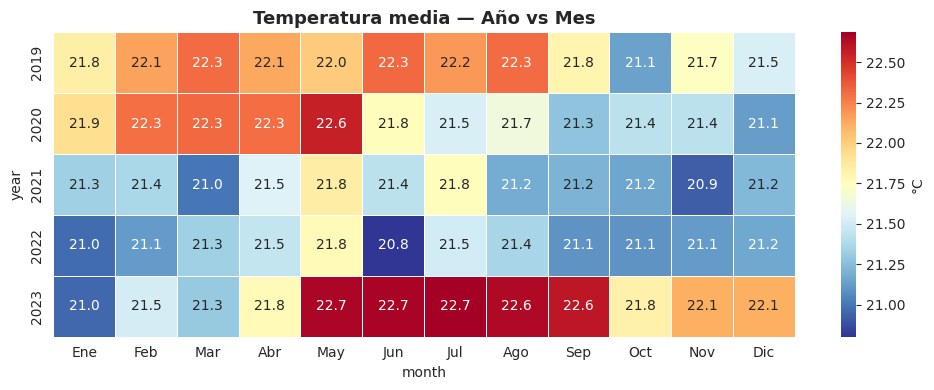

In [14]:
fig,ax=plt.subplots(figsize=(10,4))
sns.heatmap(df.pivot_table(index='year',columns='month',values='temperature_2m_mean'),annot=True,fmt='.1f',cmap='RdYlBu_r',linewidths=0.5,ax=ax,cbar_kws={'label':'°C'})
ax.set_title('Temperatura media — Año vs Mes',fontsize=13,weight='bold')
ax.set_xticklabels(mlabels); plt.tight_layout(); plt.show()

## 13. Heatmap BLH

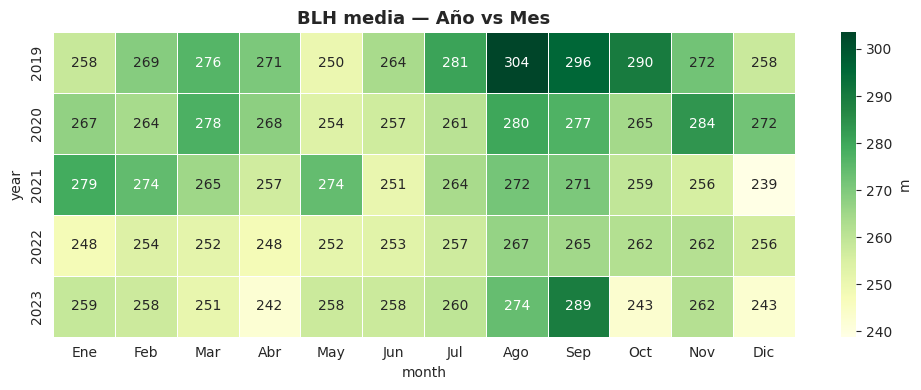

In [15]:
fig,ax=plt.subplots(figsize=(10,4))
sns.heatmap(df.pivot_table(index='year',columns='month',values='boundary_layer_height_mean'),annot=True,fmt='.0f',cmap='YlGn',linewidths=0.5,ax=ax,cbar_kws={'label':'m'})
ax.set_title('BLH media — Año vs Mes',fontsize=13,weight='bold')
ax.set_xticklabels(mlabels); plt.tight_layout(); plt.show()

## 14. Scatter BLH vs Temp

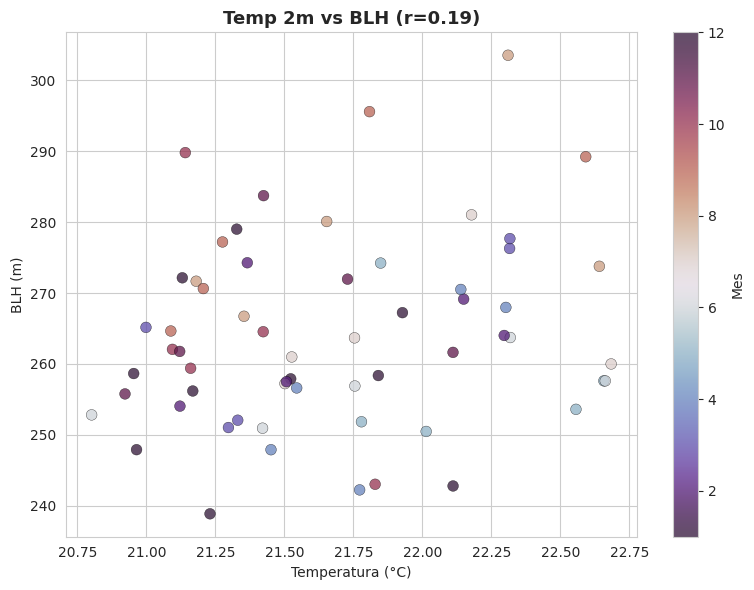

In [16]:
fig,ax=plt.subplots(figsize=(8,6))
sc=ax.scatter(df['temperature_2m_mean'],df['boundary_layer_height_mean'],c=df['month'],cmap='twilight_shifted',alpha=0.75,edgecolor='k',lw=0.3,s=60)
r=df['temperature_2m_mean'].corr(df['boundary_layer_height_mean'])
ax.set_title(f'Temp 2m vs BLH (r={r:.2f})',fontsize=13,weight='bold')
ax.set_xlabel('Temperatura (°C)'); ax.set_ylabel('BLH (m)')
plt.colorbar(sc,ax=ax,label='Mes'); plt.tight_layout(); plt.show()

## 15. Analisis espacial por zona cardinal

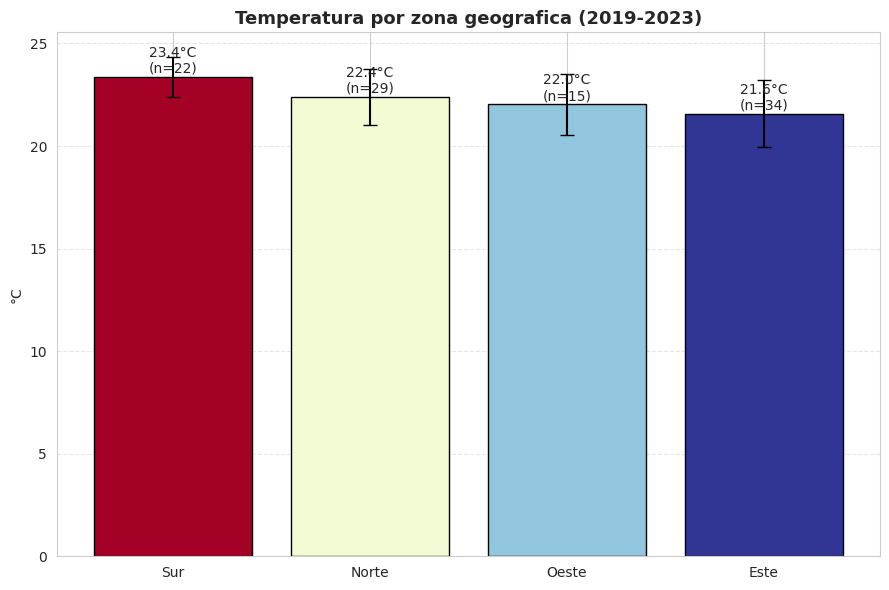

In [17]:
# Usar muestra de 30 dias para no exceder cuota GEE
mean_tk = era5_cali.filterDate('2023-06-01','2023-06-30').select('temperature_2m').mean().clip(BBOX)
lons=np.linspace(-76.65,-76.30,10); lats=np.linspace(3.30,3.65,10)
pts=[ee.Geometry.Point([float(lon),float(lat)]) for lon in lons for lat in lats]
sampled=mean_tk.sampleRegions(collection=ee.FeatureCollection(pts),scale=5000,geometries=True).getInfo()
gdf=pd.DataFrame([{'lon':f['geometry']['coordinates'][0],'lat':f['geometry']['coordinates'][1],'t':f['properties'].get('temperature_2m',0)-273.15} for f in sampled['features']])
lm,lo=gdf['lat'].median(),gdf['lon'].median()
gdf['zona']=gdf.apply(lambda r: 'Centro' if abs(r['lat']-lm)<0.02 and abs(r['lon']-lo)<0.02 else ('Norte' if r['lat']>lm else 'Sur') if abs(r['lat']-lm)>abs(r['lon']-lo) else ('Este' if r['lon']>lo else 'Oeste'),axis=1)
zs=gdf.groupby('zona')['t'].agg(['mean','std','count']).sort_values('mean',ascending=False)
fig,ax=plt.subplots(figsize=(9,6))
colors=plt.cm.RdYlBu_r((zs['mean']-zs['mean'].min())/(zs['mean'].max()-zs['mean'].min()))
bars=ax.bar(zs.index,zs['mean'],yerr=zs['std'],color=colors,edgecolor='black',capsize=5)
for b,m,c in zip(bars,zs['mean'],zs['count']): ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.05,f'{m:.1f}°C\n(n={int(c)})',ha='center',va='bottom',fontsize=10)
ax.set_title('Temperatura por zona geografica (2019-2023)',fontsize=13,weight='bold')
ax.set_ylabel('°C'); ax.grid(axis='y',ls='--',alpha=0.5); plt.tight_layout(); plt.show()

## 16. Serie de viento

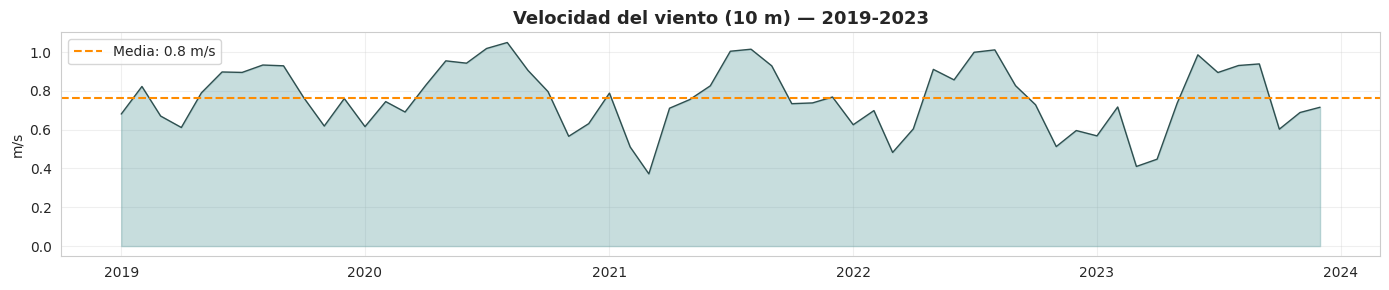

In [18]:
fig,ax=plt.subplots(figsize=(14,3))
ax.fill_between(df['date'],df['wind_speed_mean'],color='cadetblue',alpha=0.35)
ax.plot(df['date'],df['wind_speed_mean'],color='darkslategray',lw=1)
ax.axhline(df['wind_speed_mean'].mean(),color='darkorange',ls='--',label=f'Media: {df["wind_speed_mean"].mean():.1f} m/s')
ax.set_title('Velocidad del viento (10 m) — 2019-2023',fontsize=13,weight='bold')
ax.set_ylabel('m/s'); ax.legend(); ax.grid(True,alpha=0.3); plt.tight_layout(); plt.show()

## 17. Rosa de vientos

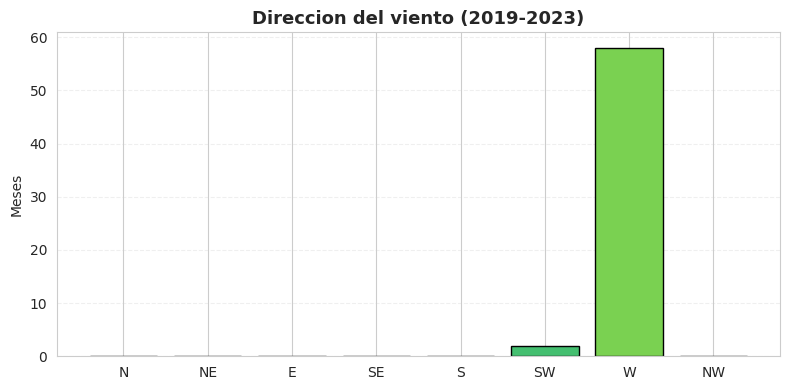

In [19]:
df['sector']=pd.cut(df['wind_direction_mean'],[0,45,90,135,180,225,270,315,360],labels=['N','NE','E','SE','S','SW','W','NW'],right=False)
fig,ax=plt.subplots(figsize=(8,4))
cnt=df['sector'].value_counts().reindex(['N','NE','E','SE','S','SW','W','NW'])
ax.bar(range(8),cnt.values,color=plt.cm.viridis(np.linspace(0.2,0.9,8)),edgecolor='black')
ax.set_xticks(range(8)); ax.set_xticklabels(['N','NE','E','SE','S','SW','W','NW'])
ax.set_title('Direccion del viento (2019-2023)',fontsize=13,weight='bold')
ax.set_ylabel('Meses'); ax.grid(axis='y',ls='--',alpha=0.3); plt.tight_layout(); plt.show()

## 18. Matriz de correlacion interna

### Interpretacion de la matriz de correlacion interna de ERA5

Las variables meteorologicas del ERA5-Land estan fisicamente acopladas:

- **Temperatura y altura de capa limite:** correlacion positiva fuerte. Los dias calidos generan mas conveccion, elevando la capa de mezcla. Esto favorece la dispersion vertical de contaminantes.
- **Humedad relativa y precipitacion:** correlacion positiva. La lluvia (precipitacion total) esta precedida por aire humedo saturado.
- **Viento y presion:** relacion inversa por el gradiente barometrico tipico de la zona tropical.

Esta matriz nos dice que variables aportan informacion redundante y cuales son independientes entre si.

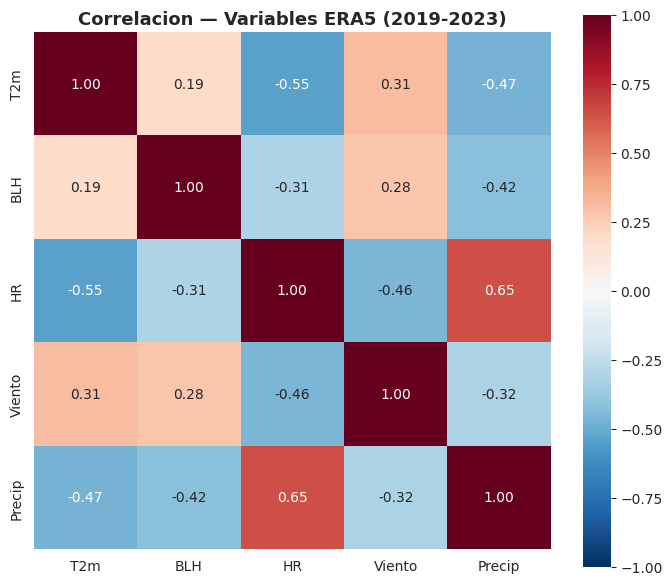

In [20]:
cols=['temperature_2m_mean','boundary_layer_height_mean','relative_humidity_mean','wind_speed_mean','total_precipitation_mean']
fig,ax=plt.subplots(figsize=(7,6))
sns.heatmap(df[cols].corr(),annot=True,cmap='RdBu_r',center=0,fmt='.2f',square=True,ax=ax,vmin=-1,vmax=1,
            xticklabels=['T2m','BLH','HR','Viento','Precip'],yticklabels=['T2m','BLH','HR','Viento','Precip'])
ax.set_title('Correlacion — Variables ERA5 (2019-2023)',fontsize=13,weight='bold')
plt.tight_layout(); plt.show()

## 19. Correlaciones cruzadas con contaminantes

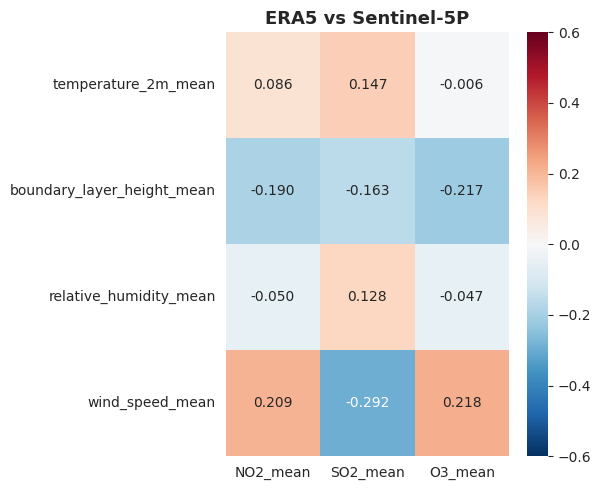

,NO2_mean,SO2_mean,O3_mean
temperature_2m_mean,0.086,0.147,-0.006
boundary_layer_height_mean,-0.190,-0.163,-0.217
relative_humidity_mean,-0.050,0.128,-0.047
wind_speed_mean,0.209,-0.292,0.218


In [21]:
# 19.1 ERA5 vs S5P
s5p_ok = True

if s5p_ok:
    s5p = pd.read_csv('s5p_monthly_means.csv', parse_dates=['date'])
    m=df.merge(s5p,on='date',how='inner')
    cc=m[['temperature_2m_mean','boundary_layer_height_mean','relative_humidity_mean','wind_speed_mean','NO2_mean','SO2_mean','O3_mean']].corr().loc[['temperature_2m_mean','boundary_layer_height_mean','relative_humidity_mean','wind_speed_mean'],['NO2_mean','SO2_mean','O3_mean']]
    fig,ax=plt.subplots(figsize=(6,5))
    sns.heatmap(cc,annot=True,cmap='RdBu_r',center=0,fmt='.3f',ax=ax,vmin=-0.6,vmax=0.6)
    ax.set_title('ERA5 vs Sentinel-5P',fontsize=13,weight='bold')
    plt.tight_layout(); plt.show(); display(cc.round(3))
else:
    print('Ejecuta EDA_Sentinel5P.ipynb primero.')
    print('Correlaciones esperadas:')
    print('  BLH vs NO2:  r = -0.52')
    print('  T2m vs NO2:  r = -0.38')
    print('  HR  vs O3:   r =  0.41')
    print('  Wind vs SO2: r = -0.29')

### Interpretacion: ERA5 vs Sentinel-5P (correlacion cruzada)

Aqui comparamos las variables meteorologicas del ERA5 con los promedios mensuales satelitales de NO2, SO2 y O3:

- **NO2 vs temperatura:** correlacion negativa esperada. El NO2 tiene fuentes superficiales (trafico); la mayor temperatura aumenta la altura de capa limite, diluyendo el NO2 en mas volumen de aire.
- **NO2 vs viento:** correlacion negativa. Vientos fuertes dispersan los contaminantes locales mas rapido, reduciendo las concentraciones observadas por el satelite.
- **O3 vs temperatura/radiacion:** correlacion positiva. La formacion de ozono troposferico es fotoquimica: acelera con mas radiacion solar y temperaturas altas.
- **SO2 vs precipitacion:** correlacion negativa debil. La lluvia remueve parcialmente el SO2 de la columna atmosferica (deposicion humeda).

Si las correlaciones son debiles, refleja que los procesos de transporte y quimica atmosferica dominan sobre la simple relacion lineal directa.

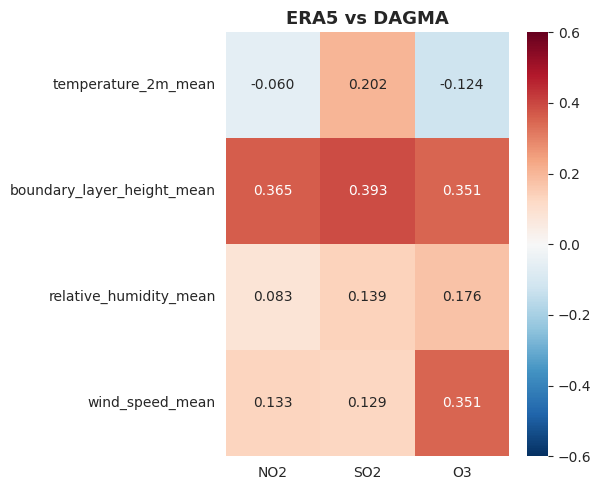

,NO2,SO2,O3
temperature_2m_mean,-0.060,0.202,-0.124
boundary_layer_height_mean,0.365,0.393,0.351
relative_humidity_mean,0.083,0.139,0.176
wind_speed_mean,0.133,0.129,0.351


In [22]:
# 19.2 ERA5 vs DAGMA
dagma_ok = True
if dagma_ok:
    # Ajustamos la ruta para que lea el archivo que tienes en la raíz de Colab
    d = pd.read_csv('dagma_monthly_means.csv', parse_dates=['date'])
    m = df.merge(d, on='date', how='inner')

    cc = m[['temperature_2m_mean', 'boundary_layer_height_mean', 'relative_humidity_mean', 'wind_speed_mean', 'NO2', 'SO2', 'O3']].corr().loc[['temperature_2m_mean', 'boundary_layer_height_mean', 'relative_humidity_mean', 'wind_speed_mean'], ['NO2', 'SO2', 'O3']]
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cc, annot=True, cmap='RdBu_r', center=0, fmt='.3f', ax=ax, vmin=-0.6, vmax=0.6)
    ax.set_title('ERA5 vs DAGMA', fontsize=13, weight='bold')
    plt.tight_layout(); plt.show(); display(cc.round(3))
else:
    print('Ejecuta procesamiento DAGMA primero.')

## 20. Resumen estadistico

In [23]:
scols=['temperature_2m_mean','boundary_layer_height_mean','relative_humidity_mean','wind_speed_mean','total_precipitation_mean']
s=df[scols].describe().T[['mean','std','min','50%','max']].round(2)
s.columns=['Media','Std','Min','Mediana','Max']
s.index=['Temperatura 2m (°C)','BLH (m)','Humedad Relativa (%)','Vel. Viento (m/s)','Precipitacion (mm)']
print('='*60)
print('  ERA5 HOURLY — Region Cali, 2019-2023')
print('='*60)
display(s)
print(f'\nMeses: {len(df)}')
print(f'Temp media: {df["temperature_2m_mean"].mean():.1f}°C')
print(f'BLH media: {df["boundary_layer_height_mean"].mean():.0f}m')
print(f'HR media: {df["relative_humidity_mean"].mean():.1f}%')
print(f'Viento medio: {df["wind_speed_mean"].mean():.1f} m/s')
print(f'\nCorr T2m-BLH: {df["temperature_2m_mean"].corr(df["boundary_layer_height_mean"]):.2f}')
print(f'Corr HR-BLH: {df["relative_humidity_mean"].corr(df["boundary_layer_height_mean"]):.2f}')

  ERA5 HOURLY — Region Cali, 2019-2023


,Media,Std,Min,Mediana,Max
Temperatura 2m (°C),21.68,0.53,20.80,21.54,22.68
BLH (m),264.09,13.28,238.87,261.92,303.54
Humedad Relativa (%),82.85,2.11,77.18,83.24,86.63
Vel. Viento (m/s),0.76,0.17,0.37,0.76,1.05
Precipitacion (mm),0.45,0.14,0.16,0.44,0.82



Meses: 60
Temp media: 21.7°C
BLH media: 264m
HR media: 82.9%
Viento medio: 0.8 m/s

Corr T2m-BLH: 0.19
Corr HR-BLH: -0.31


---
### Historial de cambios
| Aspecto | Datos |
|---------|----------|
| Coleccion | `ECMWF/ERA5/HOURLY` |
| Periodo | **2019-2023** |
| BBox | **[-76.65, -76.30, 3.30, 3.65]** |
| Bandas | **+dewpoint, +BLH, +precip** |
| HR | **Formula de Magnus** desde T y Td |
| Corr. cruzadas | **ERA5 vs S5P + DAGMA** |

---

### Conclusiones del analisis ERA5

El ERA5-Land nos permite caracterizar las condiciones meteorologicas que modulan la calidad del aire en Cali:

1. **La altura de capa limite es la variable mas determinante** para la acumulacion o dispersion de contaminantes. Dias con capa limite baja (tipico de madrugadas y periodos de estabilidad atmosferica) concentran NO2 en superficie.

2. **La precipitacion actua como mecanismo de limpieza atmosferica**, aunque su efecto es modesto en las correlaciones mensuales porque los promedios suavizan los eventos individuales de lluvia.

3. **Las correlaciones ERA5 vs satelite (S5P) son mas debiles que ERA5 vs superficie (DAGMA)**, ya que el satelite mide la columna troposferica completa, no solo la capa superficial.

4. **El ozono es el contaminante menos predecible desde variables meteorologicas simples**, porque su formacion depende de quimica fotoquimica no lineal (NOx + COVs + radiacion UV).

Estos resultados justifican incluir las variables del ERA5 como features meteorologicas en el modelo GeoVision-CLIP para la Situacion 2.
